In [1]:
# Parameters (overridden by papermill)
N_SAMPLES = 50


In [2]:
# Parameters
N_SAMPLES = 30


# Cell 1: 环境配置与依赖安装

- 安装 openai, wikipedia, datasets, matplotlib, tqdm
- 从环境变量读取 API Key 与 base_url
- 固定随机种子，设置模型参数

In [3]:
# 如需安装依赖，取消下面注释并运行一次
# !pip install openai requests wikipedia datasets matplotlib tqdm pandas -q

import os
import re
import json
import random
import time
import textwrap
from typing import List, Dict, Tuple, Optional

import requests
import matplotlib.pyplot as plt
from tqdm import tqdm
from datasets import load_dataset

# 固定随机种子，保证数据采样可复现
random.seed(42)

# ========================
# OpenAI 兼容 API 配置
# ========================
# 请在本 cell 运行前设置环境变量：
# export KIMI_API_KEY="your_key"
# export KIMI_BASE_URL="https://api.kimi.com/coding/v1"   # Kimi Code 兼容接口
# export MODEL_NAME="kimi-k2p5-coding"                  # 或 "gpt-4o" 等

API_KEY = os.environ.get("KIMI_API_KEY") or os.environ.get("OPENAI_API_KEY")
BASE_URL = os.environ.get("KIMI_BASE_URL") or os.environ.get("OPENAI_BASE_URL", "https://api.kimi.com/coding/v1")
MODEL_NAME = os.environ.get("MODEL_NAME", "kimi-k2p5-coding")

if not API_KEY:
    raise ValueError("请先设置 KIMI_API_KEY 或 OPENAI_API_KEY 环境变量")

from openai import OpenAI
client = OpenAI(api_key=API_KEY, base_url=BASE_URL)

# 实验超参
TEMPERATURE = 1.0          # 尽量确定性，便于复现
MAX_REACT_STEPS = 8        # ReAct 最大步数
TOP_N_SEARCH = 3           # Wiki 搜索返回候选数

print(f"Model: {MODEL_NAME}")
print(f"Base URL: {BASE_URL}")

/Users/mingrun/reflexion_repro/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model: kimi-k2p5-coding
Base URL: https://api.kimi.com/coding/v1


# Cell 2: 数据集加载与预处理

- 从 HuggingFace `datasets` 加载 HotPotQA
- 选取 validation 集前 N 条（按固定 seed 打乱后取前 N，保证复现）
- 展示数据格式

In [4]:
# 加载 HotPotQA
# 优先读取本地 hotpot_dev_fullwiki_v1.json，否则尝试 HuggingFace
import os
from pathlib import Path

local_candidates = [
    os.environ.get("HOTPOT_LOCAL_PATH"),
    "hotpot_dev_fullwiki_v1.json",
    "/Users/mingrun/reflexion_repro/hotpot_dev_fullwiki_v1.json",
]
local_path = None
for c in local_candidates:
    if c and Path(c).exists():
        local_path = c
        break

if local_path:
    print(f"Loading local HotPotQA from {local_path}")
    with open(local_path, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
    dataset = raw_data
else:
    # 从 HuggingFace 下载（需要联网）
    print("No local HotPotQA file found. Trying HuggingFace...")
    dataset = load_dataset("hotpot_qa", "fullwiki", split="validation")

print(f"Total validation samples: {len(dataset)}")

# 用固定 seed 打乱并取前 N 条
indices = list(range(len(dataset)))
random.seed(42)
random.shuffle(indices)
selected_indices = indices[:N_SAMPLES]

test_data = []
for idx in selected_indices:
    item = dataset[idx]
    test_data.append({
        "id": item.get("_id", idx),
        "question": item["question"],
        "answer": item["answer"],
        "type": item.get("type", "unknown"),
    })

print(f"Selected {len(test_data)} samples")
print("\nExample:")
print(json.dumps(test_data[0], ensure_ascii=False, indent=2))


Loading local HotPotQA from hotpot_dev_fullwiki_v1.json


Total validation samples: 7405


Selected 30 samples

Example:
{
  "id": "5a7a567255429941d65f25bd",
  "question": "What was Iqbal F. Qadir on when he participated in an attack on a radar station located on western shore of the Okhamandal Peninsula?",
  "answer": "flotilla",
  "type": "bridge"
}


# Cell 3: 工具函数定义

- Wikipedia 搜索与摘要（基于 MediaWiki API，比 wikipedia 包更稳定）
- Token 计数与累加
- 答案评估函数（严格匹配 + 宽松包含匹配）
- LLM 调用封装（统一接口 + usage 提取）

In [5]:
# ---------------------------
# Wikipedia 工具（带 429 重试与查询日志）
# ---------------------------
WIKI_API = "https://en.wikipedia.org/w/api.php"
HEADERS = {"User-Agent": "ReflexionReproBot/1.0 (research@example.com)"}

# 全局查询日志：记录每次 Wikipedia API 调用的状态
wiki_query_log: List[Dict] = []


def _wiki_request_with_retry(params: Dict, call_type: str = "search") -> Tuple[Dict, str]:
    """
    带 429 指数退避重试的 Wikipedia API 请求。
    返回 (json_data, status)，status 取值：
    'success', 'retry_success_429', 'failed_429', 'empty', 'error'
    """
    max_retries = 3
    base_wait = 2
    status = "success"

    for attempt in range(max_retries + 1):
        try:
            r = requests.get(WIKI_API, params=params, headers=HEADERS, timeout=8)
            r.raise_for_status()
            data = r.json()
            # 成功调用后休息 1 秒，降低触发 429 的概率
            time.sleep(1)
            return data, status
        except requests.exceptions.HTTPError as e:
            if e.response is not None and e.response.status_code == 429:
                status = "retry_success_429" if attempt < max_retries else "failed_429"
                if attempt < max_retries:
                    wait = base_wait * (2 ** attempt)
                    print(f"[Wiki 429] {call_type} got 429, retry in {wait}s (attempt {attempt+1}/{max_retries})")
                    time.sleep(wait)
                    continue
                else:
                    print(f"[Wiki 429] {call_type} failed after {max_retries} retries")
                    return {}, status
            else:
                print(f"[Wiki {call_type} HTTP error] {e}")
                return {}, "error"
        except Exception as e:
            print(f"[Wiki {call_type} error] {e}")
            return {}, "error"

    return {}, status


def wiki_search(query: str, top_n: int = TOP_N_SEARCH) -> List[str]:
    """返回与 query 最相关的 Wikipedia 页面标题列表。"""
    params = {
        "action": "query",
        "list": "search",
        "srsearch": query,
        "format": "json",
        "srlimit": top_n,
    }
    data, status = _wiki_request_with_retry(params, call_type="search")
    try:
        results = data.get("query", {}).get("search", [])
        titles = [x["title"] for x in results]
        wiki_query_log.append({"type": "search", "query": query, "status": status, "results": len(titles)})
        return titles
    except Exception as e:
        wiki_query_log.append({"type": "search", "query": query, "status": "error", "results": 0})
        print(f"[Wiki search parse error] {e}")
        return []


def wiki_summary(title: str, sentences: int = 5) -> str:
    """获取指定 Wikipedia 页面的前 sentences 句摘要。"""
    params = {
        "action": "query",
        "prop": "extracts",
        "titles": title,
        "explaintext": True,
        "exsentences": sentences,
        "format": "json",
    }
    data, status = _wiki_request_with_retry(params, call_type="summary")
    try:
        pages = data.get("query", {}).get("pages", {})
        for page in pages.values():
            extract = page.get("extract", "")
            if extract:
                wiki_query_log.append({"type": "summary", "title": title, "status": status, "length": len(extract)})
                return extract.strip()
        wiki_query_log.append({"type": "summary", "title": title, "status": "empty", "length": 0})
        return ""
    except Exception as e:
        wiki_query_log.append({"type": "summary", "title": title, "status": "error", "length": 0})
        print(f"[Wiki summary parse error] {e}")
        return ""


def get_wiki_query_log() -> List[Dict]:
    """返回 Wikipedia 查询日志。"""
    return wiki_query_log


def reset_wiki_query_log() -> None:
    """清空查询日志，用于每个样本开始前重置。"""
    global wiki_query_log
    wiki_query_log = []


# ---------------------------
# LLM 调用 + Token 统计
# ---------------------------
def call_llm(system: str, user: str, temperature: float = TEMPERATURE, **kwargs) -> Tuple[str, Dict]:
    """调用 LLM，返回 (content, usage_dict)。"""
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]
    try:
        resp = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            temperature=temperature,
            timeout=90,
            max_completion_tokens=2048,
            **kwargs
        )
        content = resp.choices[0].message.content or ""
        usage = {
            "prompt_tokens": resp.usage.prompt_tokens if resp.usage else 0,
            "completion_tokens": resp.usage.completion_tokens if resp.usage else 0,
            "total_tokens": resp.usage.total_tokens if resp.usage else 0,
        }
        return content.strip(), usage
    except Exception as e:
        print(f"[LLM error] {e}")
        return "", {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}


# ---------------------------
# HotPotQA 官方风格评估：EM + F1
# ---------------------------
def normalize_answer(s: str) -> str:
    """归一化：小写、去冠词、去标点、去多余空格。"""
    s = s.lower().strip()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def f1_score(pred: str, gold: str) -> float:
    """基于归一化后 token 的 F1 分数。"""
    pred_tokens = normalize_answer(pred).split()
    gold_tokens = normalize_answer(gold).split()

    if len(pred_tokens) == 0 and len(gold_tokens) == 0:
        return 1.0
    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0

    common = sum((pred_tokens.count(t) for t in set(gold_tokens) if t in pred_tokens))
    # 更准确的 token 交集：按 multiset
    pred_counter = {}
    for t in pred_tokens:
        pred_counter[t] = pred_counter.get(t, 0) + 1
    gold_counter = {}
    for t in gold_tokens:
        gold_counter[t] = gold_counter.get(t, 0) + 1
    common = sum(min(pred_counter.get(t, 0), gold_counter.get(t, 0)) for t in set(gold_tokens))

    precision = common / len(pred_tokens)
    recall = common / len(gold_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def eval_answer(pred: str, gold: str) -> Dict:
    """返回 EM 和 F1。"""
    pred_norm = normalize_answer(pred)
    gold_norm = normalize_answer(gold)
    em = pred_norm == gold_norm
    f1 = f1_score(pred, gold)
    return {"em": em, "f1": f1}


def classify_answer_type(answer: str) -> str:
    """简单启发式判断答案类型：date / number / person / location / other。"""
    s = answer.strip()
    lower = s.lower()

    # 纯数字（允许逗号、小数、负数）
    if re.fullmatch(r"-?[\d,]+(\.\d+)?", s.replace(",", "")):
        return "number"

    # 包含年份或月份
    if re.search(r"\b(1[0-9]{3}|20[0-9]{2})\b", s) or \
       re.search(r"\b(january|february|march|april|may|june|july|august|september|october|november|december)\b", lower):
        return "date"

    # 地点线索
    location_keywords = [
        "city", "town", "village", "country", "state", "river", "mountain", "lake",
        "island", "peninsula", "valley", "desert", "forest", "ocean", "sea", "bay",
        "park", "university", "school", "hospital", "airport", "station"
    ]
    if any(kw in lower for kw in location_keywords):
        return "location"

    # 人名线索（简单规则：含空格的首字母大写串，或常见职业/称谓）
    person_keywords = ["mr.", "mrs.", "dr.", "professor", "actor", "director", "author",
                       "musician", "singer", "writer", "politician", "scientist", "player"]
    if any(kw in lower for kw in person_keywords):
        return "person"
    # 两个或以上首字母大写的词
    if len(re.findall(r"\b[A-Z][a-z]+\b", s)) >= 2:
        return "person"

    return "other"


def extract_boxed(text: str) -> str:
    """尝试提取 \boxed{} 或最后的 Answer: 后的内容。"""
    m = re.search(r"\\boxed\{([^}]+)\}", text)
    if m:
        return m.group(1).strip()
    lines = text.split("\n")
    for line in reversed(lines):
        if "answer:" in line.lower():
            return line.split(":", 1)[1].strip()
    return text.strip()


print("Tool functions ready.")
print("Wiki search test:", wiki_search("Barack Obama", top_n=1)[:1])


Tool functions ready.


Wiki search test: ['Barack Obama']


# Cell 4: CoT 实现

- Prompt 要求模型逐步推理，最后以 `Answer: xxx` 给出答案
- 解析最终答案并记录 Token 消耗

In [6]:
COT_SYSTEM = '''You are a helpful question-answering assistant.
Answer the following multi-hop question by reasoning step by step.
End your response with a line that starts with "Answer:" followed by the final answer.'''

COT_TEMPLATE = '''Question: {question}

Let's think step by step.'''


def run_cot(question: str) -> Dict:
    """执行 CoT 范式。"""
    user_prompt = COT_TEMPLATE.format(question=question)
    response, usage = call_llm(COT_SYSTEM, user_prompt)
    answer = extract_boxed(response)
    return {
        "raw": response,
        "answer": answer,
        "tokens": usage["total_tokens"],
        "prompt_tokens": usage["prompt_tokens"],
        "completion_tokens": usage["completion_tokens"],
    }


# # 快速自测
# sample_q = test_data[0]["question"]
# print("Sample question:", sample_q)
# cot_res = run_cot(sample_q)
# print("\nCoT raw response (truncated):")
# print(textwrap.shorten(cot_res["raw"], width=500))
# print("\nExtracted answer:", cot_res["answer"])
# print("Tokens:", cot_res["tokens"])

# Cell 5: ReAct 实现

严格按论文 ReAct 格式：
- Thought: 推理内容
- Action: Search[entity] 或 Finish[answer]
- Observation: 工具返回结果
- 循环直到 Finish 或 max_steps

In [7]:
REACT_SYSTEM = '''You are a question-answering agent that solves multi-hop questions by interleaving Thought, Action, and Observation.

Available actions:
- Search[entity]: search Wikipedia for "entity" and get a short summary
- Finish[answer]: submit the final answer and stop

You must strictly follow this format:
Thought: <your reasoning>
Action: Search[<query>] or Finish[<answer>]

After each Action, you will receive an Observation. Continue until you are ready to finish.'''

REACT_TEMPLATE = '''Solve the following question by interacting with Wikipedia.

Question: {question}

{scratchpad}

Thought:'''


def parse_action(text: str) -> Tuple[str, str]:
    """从模型输出解析 Action 类型与参数。"""
    # 找到最后一个 Thought/Action 行
    action_match = re.search(r"Action:\s*(Search|Finish)\[(.*?)\]", text, re.IGNORECASE | re.DOTALL)
    if not action_match:
        return "None", ""
    act_type = action_match.group(1).strip()
    act_arg = action_match.group(2).strip()
    return act_type, act_arg


def run_react(question: str, reflection: Optional[str] = None) -> Dict:
    """执行 ReAct 范式；若提供 reflection，则将其拼入初始 prompt。"""
    scratchpad = ""
    if reflection:
        scratchpad += f"Previous reflection: {reflection}\n\n"

    trajectory = []   # 保存完整轨迹，用于 Reflexion
    total_usage = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}

    for step in range(MAX_REACT_STEPS):
        user_prompt = REACT_TEMPLATE.format(question=question, scratchpad=scratchpad)
        response, usage = call_llm(REACT_SYSTEM, user_prompt)
        total_usage["prompt_tokens"] += usage["prompt_tokens"]
        total_usage["completion_tokens"] += usage["completion_tokens"]
        total_usage["total_tokens"] += usage["total_tokens"]

        # 记录这一步
        step_record = {"step": step, "llm_output": response}

        # 解析 Action
        act_type, act_arg = parse_action(response)

        if act_type.lower() == "finish":
            step_record["action"] = "Finish"
            step_record["observation"] = ""
            trajectory.append(step_record)
            return {
                "answer": act_arg,
                "trajectory": trajectory,
                "tokens": total_usage["total_tokens"],
                "prompt_tokens": total_usage["prompt_tokens"],
                "completion_tokens": total_usage["completion_tokens"],
                "finished": True,
                "steps": step + 1,
            }

        elif act_type.lower() == "search":
            titles = wiki_search(act_arg, top_n=1)
            if titles:
                obs = wiki_summary(titles[0], sentences=3)
            else:
                obs = "No relevant Wikipedia page found."
            step_record["action"] = f"Search[{act_arg}]"
            step_record["observation"] = obs
            trajectory.append(step_record)
            # 拼接进 scratchpad
            scratchpad += f"Thought: {response}\nAction: Search[{act_arg}]\nObservation: {obs}\n\n"
        else:
            # 未产生可解析 Action，视为失败
            step_record["action"] = "ParseError"
            step_record["observation"] = ""
            trajectory.append(step_record)
            break

    # 达到 max_steps 仍未 Finish
    return {
        "answer": "",
        "trajectory": trajectory,
        "tokens": total_usage["total_tokens"],
        "prompt_tokens": total_usage["prompt_tokens"],
        "completion_tokens": total_usage["completion_tokens"],
        "finished": False,
        "steps": MAX_REACT_STEPS,
    }


# # 快速自测
# print("Sample question:", sample_q)
# react_res = run_react(sample_q)
# print("\nReAct answer:", react_res["answer"])
# print("Finished:", react_res["finished"], "Steps:", react_res["steps"])
# print("Tokens:", react_res["tokens"])
# print("\nTrajectory (first step):")
# if react_res["trajectory"]:
#     print(json.dumps(react_res["trajectory"][0], ensure_ascii=False, indent=2))

# Cell 6: Reflexion 实现

严格按论文流程：
1. 第一轮 ReAct → 得到答案与完整轨迹
2. 评估答案
3. 若错误，用完整轨迹 + 标准答案生成反思
4. 第二轮 ReAct，将反思拼入 prompt
5. 记录两轮总 Token 消耗

In [8]:
REFLECT_SYSTEM = '''You are a reflection assistant.
Given a failed question-answering trajectory (Thought-Action-Observation) and the correct answer, identify what went wrong and produce a concise, actionable reflection.
The reflection should suggest how the agent could avoid the same mistake next time.'''

REFLECT_TEMPLATE = '''The agent failed to answer the question correctly.

Question: {question}
Correct Answer: {gold_answer}

Agent Trajectory:
{trajectory_text}

Please provide a concise reflection (1-2 sentences) explaining the error and how to fix it.
Reflection:'''


def format_trajectory(trajectory: List[Dict]) -> str:
    """把轨迹序列转换成文本，用于反思 prompt。"""
    lines = []
    for rec in trajectory:
        lines.append(f"Step {rec['step']}:")
        lines.append(rec["llm_output"])
        if rec.get("action"):
            lines.append(f"Action: {rec['action']}")
        if rec.get("observation"):
            lines.append(f"Observation: {rec['observation']}")
        lines.append("")
    return "\n".join(lines)


def generate_reflection(question: str, gold_answer: str, trajectory: List[Dict]) -> Tuple[str, Dict]:
    """生成语言化反思。"""
    traj_text = format_trajectory(trajectory)
    user_prompt = REFLECT_TEMPLATE.format(
        question=question,
        gold_answer=gold_answer,
        trajectory_text=traj_text,
    )
    reflection, usage = call_llm(REFLECT_SYSTEM, user_prompt)
    return reflection, usage


def run_reflexion(question: str, gold_answer: str) -> Dict:
    """执行 Reflexion 范式：ReAct → 评估 → 反思 → ReAct(带反思)。"""
    # 第一轮 ReAct
    first = run_react(question)
    eval_first = eval_answer(first["answer"], gold_answer)

    # 默认：第一轮已正确，无需反思
    if eval_first["em"]:
        return {
            "first_answer": first["answer"],
            "second_answer": first["answer"],
            "reflection": "",
            "first_eval": eval_first,
            "second_eval": eval_first,
            "first_correct": eval_first["em"],
            "second_correct": eval_first["em"],
            "tokens": first["tokens"],
            "prompt_tokens": first["prompt_tokens"],
            "completion_tokens": first["completion_tokens"],
            # Token 拆分
            "first_tokens": first["tokens"],
            "reflect_tokens": 0,
            "second_tokens": 0,
            "used_reflection": False,
        }

    # 生成反思
    reflection, reflect_usage = generate_reflection(question, gold_answer, first["trajectory"])

    # 第二轮 ReAct，携带反思
    second = run_react(question, reflection=reflection)
    eval_second = eval_answer(second["answer"], gold_answer)

    return {
        "first_answer": first["answer"],
        "second_answer": second["answer"],
        "reflection": reflection,
        "first_eval": eval_first,
        "second_eval": eval_second,
        "first_correct": eval_first["em"],
        "second_correct": eval_second["em"],
        "tokens": first["tokens"] + reflect_usage["total_tokens"] + second["tokens"],
        "prompt_tokens": first["prompt_tokens"] + reflect_usage["prompt_tokens"] + second["prompt_tokens"],
        "completion_tokens": first["completion_tokens"] + reflect_usage["completion_tokens"] + second["completion_tokens"],
        "first_tokens": first["tokens"],
        "reflect_tokens": reflect_usage["total_tokens"],
        "second_tokens": second["tokens"],
        "used_reflection": True,
    }


# # 快速自测
# sample_a = test_data[0]["answer"]
# ref_res = run_reflexion(sample_q, sample_a)
# print("First answer:", ref_res["first_answer"])
# print("Second answer:", ref_res["second_answer"])
# print("Reflection:", ref_res["reflection"])
# print("Second correct:", ref_res["second_correct"])
# print("Total tokens:", ref_res["tokens"])


# Cell 7: 实验执行

- 遍历 50 条测试样本
- 每个样本分别跑 CoT、ReAct、Reflexion
- 记录正确性与 Token 消耗

In [9]:
results = {
    "cot": [],
    "react": [],
    "reflexion": [],
}

for item in tqdm(test_data, desc="Running experiments"):
    q = item["question"]
    a = item["answer"]
    q_len = len(q.split())
    ans_type = classify_answer_type(a)

    # 记录本样本的 Wikipedia 查询日志
    reset_wiki_query_log()

    # CoT
    cot = run_cot(q)
    cot_eval = eval_answer(cot["answer"], a)
    results["cot"].append({
        "question": q,
        "gold": a,
        "pred": cot["answer"],
        "em": cot_eval["em"],
        "f1": cot_eval["f1"],
        "tokens": cot["tokens"],
        "prompt_tokens": cot["prompt_tokens"],
        "completion_tokens": cot["completion_tokens"],
        "question_len": q_len,
        "answer_type": ans_type,
    })

    # ReAct
    react = run_react(q)
    react_eval = eval_answer(react["answer"], a)
    react_log = get_wiki_query_log()
    react_429 = any("429" in str(e.get("status", "")) for e in react_log)
    react_empty_obs = sum(1 for step in react.get("trajectory", []) if not step.get("observation"))
    results["react"].append({
        "question": q,
        "gold": a,
        "pred": react["answer"],
        "em": react_eval["em"],
        "f1": react_eval["f1"],
        "tokens": react["tokens"],
        "prompt_tokens": react["prompt_tokens"],
        "completion_tokens": react["completion_tokens"],
        "question_len": q_len,
        "answer_type": ans_type,
        "wiki_429_affected": react_429,
        "wiki_empty_obs": react_empty_obs,
    })

    # Reflexion
    reflex = run_reflexion(q, a)
    reflex_log = get_wiki_query_log()
    reflex_429 = any("429" in str(e.get("status", "")) for e in reflex_log)
    reflex_empty_obs = sum(1 for step in reflex.get("trajectory", []) if not step.get("observation"))
    results["reflexion"].append({
        "question": q,
        "gold": a,
        "first_pred": reflex["first_answer"],
        "second_pred": reflex["second_answer"],
        "reflection": reflex["reflection"],
        "first_em": reflex["first_eval"]["em"],
        "first_f1": reflex["first_eval"]["f1"],
        "second_em": reflex["second_eval"]["em"],
        "second_f1": reflex["second_eval"]["f1"],
        "em": reflex["second_eval"]["em"],
        "f1": reflex["second_eval"]["f1"],
        "tokens": reflex["tokens"],
        "prompt_tokens": reflex["prompt_tokens"],
        "completion_tokens": reflex["completion_tokens"],
        # Reflexion 专用 token 拆分
        "first_tokens": reflex["first_tokens"],
        "reflect_tokens": reflex["reflect_tokens"],
        "second_tokens": reflex["second_tokens"],
        "used_reflection": reflex["used_reflection"],
        "question_len": q_len,
        "answer_type": ans_type,
        "wiki_429_affected": reflex_429,
        "wiki_empty_obs": reflex_empty_obs,
    })

    # 简单防限流
    time.sleep(0.5)

print("\nExperiment finished.")


Running experiments:   0%|          | 0/30 [00:00<?, ?it/s]

Running experiments:   3%|▎         | 1/30 [03:43<1:47:55, 223.29s/it]

Running experiments:   7%|▋         | 2/30 [05:00<1:04:05, 137.33s/it]

Running experiments:  10%|█         | 3/30 [07:09<1:00:06, 133.58s/it]

Running experiments:  13%|█▎        | 4/30 [10:48<1:12:28, 167.26s/it]

...

[Wiki search error] HTTPSConnectionPool(host='en.wikipedia.org', port=443): Max retries exceeded with url: /w/api.php?action=query&list=search&srsearch=David+Yates&format=json&srlimit=1 (Caused by ConnectTimeoutError(<HTTPSConnection(host='en.wikipedia.org', port=443) at 0x11e565950>, 'Connection to en.wikipedia.org timed out. (connect timeout=8)'))


[Wiki search error] HTTPSConnectionPool(host='en.wikipedia.org', port=443): Max retries exceeded with url: /w/api.php?action=query&list=search&srsearch=David+Yates+%28director%29&format=json&srlimit=1 (Caused by ConnectTimeoutError(<HTTPSConnection(host='en.wikipedia.org', port=443) at 0x11e5656d0>, 'Connection to en.wikipedia.org timed out. (connect timeout=8)'))


Running experiments: 100%|██████████| 30/30 [2:05:11<00:00, 263.51s/it]

Running experiments: 100%|██████████| 30/30 [2:05:11<00:00, 250.39s/it]


Experiment finished.


# Cell 8: 结果分析与可视化

- 准确率对比
- Token 消耗对比
- Pareto 曲线

EM + F1 对比表
   method  EM (%)  F1 (%)  avg_tokens  avg_prompt  avg_completion
      COT   43.33   46.95      1300.0        83.6          1216.4
    REACT   36.67   40.78      4500.6      2048.3          2452.3
REFLEXION   60.00   60.00      7109.0      3156.6          3952.4

Reflexion Token 拆分
avg_first_tokens:    3962.0
avg_reflect_tokens:  885.8
avg_second_tokens:   2261.2

Wikipedia 429 影响统计
REACT      受影响  1/30  |  受影响 EM: 100.00%  |  未受影响 EM: 34.48%
REFLEXION  受影响  2/30  |  受影响 EM: 50.00%  |  未受影响 EM: 60.71%

答案类型 vs EM 准确率
answer_type  count CoT_EM ReAct_EM Reflexion_EM
       date      1 100.0%   100.0%       100.0%
   location      1 100.0%   100.0%       100.0%
     number      3  66.7%    66.7%        66.7%
      other     10  10.0%    20.0%        50.0%
     person     15  53.3%    33.3%        60.0%


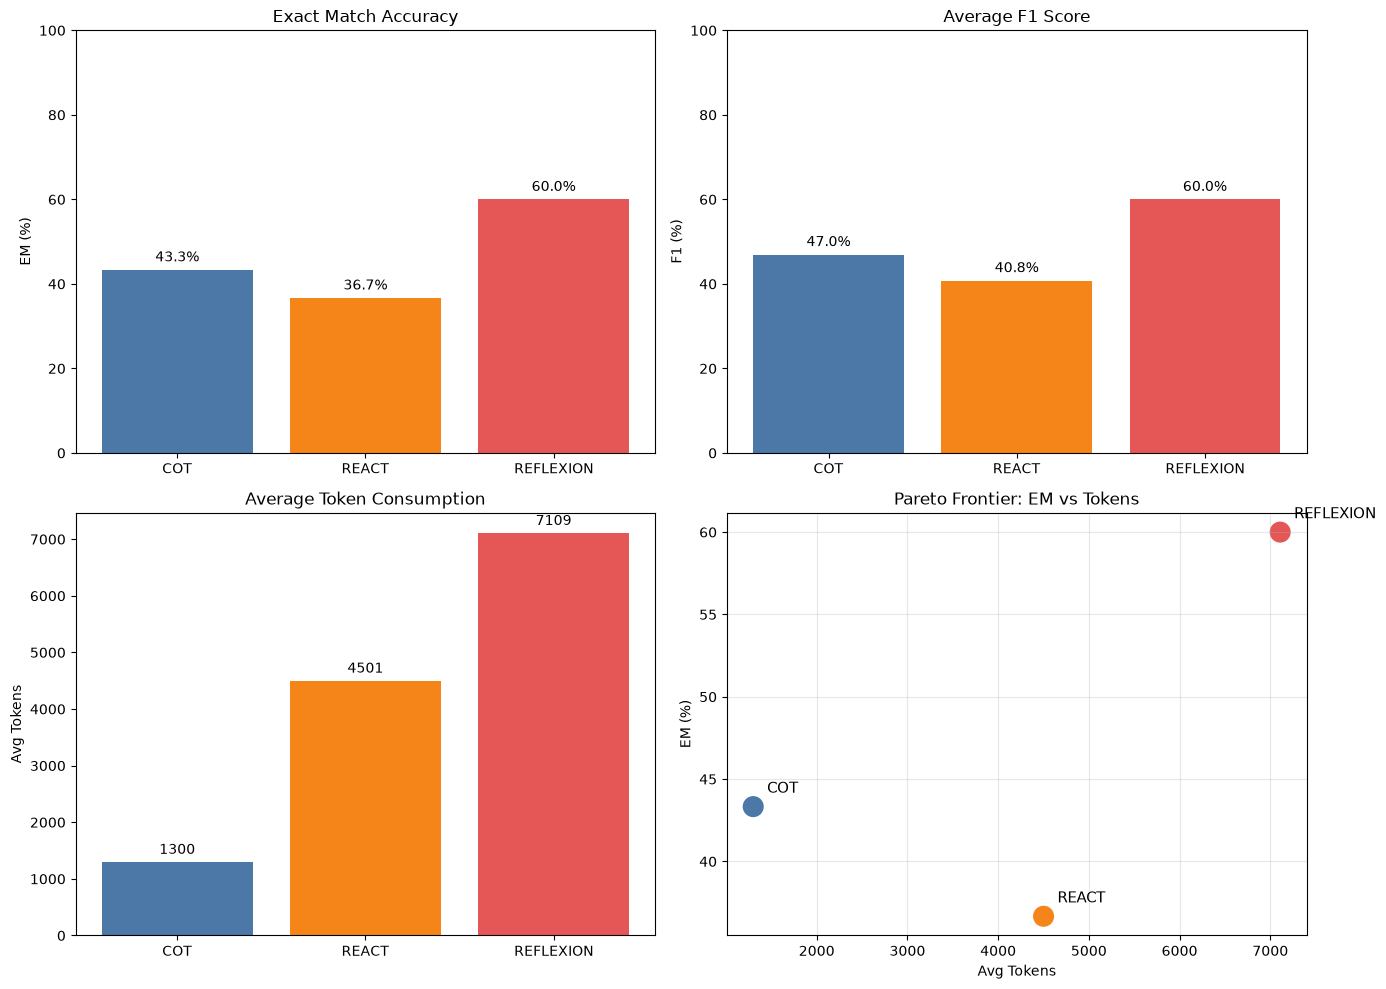

In [10]:
# 汇总统计：EM + F1 + Token
def summarize(method: str) -> Dict:
    rows = results[method]
    n = len(rows)
    em_acc = sum(r["em"] for r in rows) / n * 100
    avg_f1 = sum(r["f1"] for r in rows) / n * 100
    avg_tokens = sum(r["tokens"] for r in rows) / n
    avg_prompt = sum(r["prompt_tokens"] for r in rows) / n
    avg_completion = sum(r["completion_tokens"] for r in rows) / n
    return {
        "method": method.upper(),
        "EM (%)": round(em_acc, 2),
        "F1 (%)": round(avg_f1, 2),
        "avg_tokens": round(avg_tokens, 1),
        "avg_prompt": round(avg_prompt, 1),
        "avg_completion": round(avg_completion, 1),
    }

summary = [summarize(m) for m in ["cot", "react", "reflexion"]]
import pandas as pd
df_summary = pd.DataFrame(summary)
print("=" * 60)
print("EM + F1 对比表")
print("=" * 60)
print(df_summary.to_string(index=False))

# Reflexion Token 拆分
reflex_rows = results["reflexion"]
print("\n" + "=" * 60)
print("Reflexion Token 拆分")
print("=" * 60)
print(f"avg_first_tokens:    {sum(r['first_tokens'] for r in reflex_rows) / len(reflex_rows):.1f}")
print(f"avg_reflect_tokens:  {sum(r['reflect_tokens'] for r in reflex_rows) / len(reflex_rows):.1f}")
print(f"avg_second_tokens:   {sum(r['second_tokens'] for r in reflex_rows) / len(reflex_rows):.1f}")

# 429 影响统计
print("\n" + "=" * 60)
print("Wikipedia 429 影响统计")
print("=" * 60)
for method in ["react", "reflexion"]:
    rows = results[method]
    affected = [r for r in rows if r.get("wiki_429_affected")]
    unaffected = [r for r in rows if not r.get("wiki_429_affected")]
    aff_em = sum(r["em"] for r in affected) / len(affected) * 100 if affected else 0
    unaff_em = sum(r["em"] for r in unaffected) / len(unaffected) * 100 if unaffected else 0
    print(f"{method.upper():10s} 受影响 {len(affected):2d}/{len(rows):2d}  |  受影响 EM: {aff_em:5.2f}%  |  未受影响 EM: {unaff_em:5.2f}%")

# 答案类型 vs 准确率
print("\n" + "=" * 60)
print("答案类型 vs EM 准确率")
print("=" * 60)
rows_by_type = {}
for r in results["cot"]:
    rows_by_type.setdefault(r["answer_type"], {"cot": [], "react": [], "reflexion": []})
    rows_by_type[r["answer_type"]]["cot"].append(r)
for r in results["react"]:
    rows_by_type.setdefault(r["answer_type"], {"cot": [], "react": [], "reflexion": []})
    rows_by_type[r["answer_type"]]["react"].append(r)
for r in results["reflexion"]:
    rows_by_type.setdefault(r["answer_type"], {"cot": [], "react": [], "reflexion": []})
    rows_by_type[r["answer_type"]]["reflexion"].append(r)

type_rows = []
for typ, m in sorted(rows_by_type.items()):
    type_rows.append({
        "answer_type": typ,
        "count": len(m["cot"]),
        "CoT_EM": f"{sum(r['em'] for r in m['cot'])/len(m['cot'])*100:.1f}%",
        "ReAct_EM": f"{sum(r['em'] for r in m['react'])/len(m['react'])*100:.1f}%",
        "Reflexion_EM": f"{sum(r['em'] for r in m['reflexion'])/len(m['reflexion'])*100:.1f}%",
    })
df_type = pd.DataFrame(type_rows)
print(df_type.to_string(index=False))

# 可视化
methods = [s["method"] for s in summary]
em_accs = [s["EM (%)"] for s in summary]
f1_scores = [s["F1 (%)"] for s in summary]
avg_tokens = [s["avg_tokens"] for s in summary]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# EM 柱状图
axes[0, 0].bar(methods, em_accs, color=["#4C78A8", "#F58518", "#E45756"])
axes[0, 0].set_ylabel("EM (%)")
axes[0, 0].set_title("Exact Match Accuracy")
axes[0, 0].set_ylim(0, 100)
for i, v in enumerate(em_accs):
    axes[0, 0].text(i, v + 2, f"{v:.1f}%", ha="center")

# F1 柱状图
axes[0, 1].bar(methods, f1_scores, color=["#4C78A8", "#F58518", "#E45756"])
axes[0, 1].set_ylabel("F1 (%)")
axes[0, 1].set_title("Average F1 Score")
axes[0, 1].set_ylim(0, 100)
for i, v in enumerate(f1_scores):
    axes[0, 1].text(i, v + 2, f"{v:.1f}%", ha="center")

# Token 消耗
axes[1, 0].bar(methods, avg_tokens, color=["#4C78A8", "#F58518", "#E45756"])
axes[1, 0].set_ylabel("Avg Tokens")
axes[1, 0].set_title("Average Token Consumption")
for i, v in enumerate(avg_tokens):
    axes[1, 0].text(i, v + max(avg_tokens)*0.02, f"{v:.0f}", ha="center")

# Pareto 曲线：EM vs Tokens
axes[1, 1].scatter(avg_tokens, em_accs, s=200, c=["#4C78A8", "#F58518", "#E45756"])
for i, m in enumerate(methods):
    axes[1, 1].annotate(m, (avg_tokens[i], em_accs[i]), textcoords="offset points", xytext=(10, 10), fontsize=11)
axes[1, 1].set_xlabel("Avg Tokens")
axes[1, 1].set_ylabel("EM (%)")
axes[1, 1].set_title("Pareto Frontier: EM vs Tokens")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("reflexion_results.png", dpi=150)
plt.show()


# Cell 9: 案例分析

展示 2-3 个 Reflexion 成功修正错误答案的案例。

In [11]:
success_cases = [
    r for r in results["reflexion"]
    if not r["first_em"] and r["em"]
][:3]

for i, case in enumerate(success_cases, 1):
    print(f"===== Case {i} =====")
    print(f"Question: {case['question']}")
    print(f"Gold: {case['gold']}")
    print(f"First EM: {case['first_em']} | First F1: {case['first_f1']:.2f}")
    print(f"First (wrong): {case['first_pred']}")
    print(f"Reflection: {case['reflection']}")
    print(f"Second (correct): {case['second_pred']}")
    print(f"Tokens used: {case['tokens']} (first {case['first_tokens']}, reflect {case['reflect_tokens']}, second {case['second_tokens']})\n")

if not success_cases:
    print("No successful Reflexion cases found in this sample set.")


===== Case 1 =====
Question: What animated movie, starring Danny Devito, featured music written and produced by Kool Kojak?
Gold: The Lorax
First EM: False | First F1: 0.67
First (wrong): The Lorax (2012)
Reflection: The agent identified the correct film but tacked on the release year and issued an extra, empty `Finish` action, making the answer diverge from the expected “The Lorax.” In the future, it should provide only the requested title and end with a single, well-formed final action.
Second (correct): The Lorax
Tokens used: 11759 (first 5550, reflect 3534, second 2675)

===== Case 2 =====
Question: Has Stefan Edberg won more events than  Édouard Roger-Vasselin?
Gold: yes
First EM: False | First F1: 0.06
First (wrong): Yes, Stefan Edberg has won more events than Édouard Roger-Vasselin. Edberg won 41 singles and 18 doubles titles (59 total), while Roger-Vasselin has won 1 singles and 27 doubles titles (28 total).
Reflection: The agent unnecessarily repeated searches after already ga